<a href="https://colab.research.google.com/github/rvs0514/demandforecasting/blob/main/3PL_Demand_Forecasting_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3PL Demand Forecasting Model
### Optimising Inventory and Resource Allocation for Third-Party Logistics

This notebook builds an end-to-end demand forecasting pipeline covering:
- Synthetic data generation (or plug in your own CSV)
- Exploratory Data Analysis with visualisations
- Feature engineering (lag features, rolling statistics, calendar features)
- Multiple models: Prophet, XGBoost, LightGBM
- Model evaluation and comparison
- Future demand forecasting
- Inventory and resource allocation recommendations


## 1. Install and Import Dependencies


In [1]:
!pip install prophet lightgbm xgboost statsmodels scikit-learn plotly --quiet


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from prophet import Prophet

import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from datetime import datetime, timedelta

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print('All libraries imported successfully.')


All libraries imported successfully.


## 2. Configuration


In [3]:
CONFIG = {
    # Set to 'csv' and provide csv_path to use your own data
    'data_source': 'synthetic',
    'csv_path': '/content/your_data.csv',

    'start_date': '2021-01-01',
    'end_date': '2024-12-31',

    # How many days ahead to forecast
    'forecast_days': 90,

    # Days to hold out for testing
    'test_size_days': 90,

    'skus': ['Apparel', 'FMCG', 'Industrial'],

    # z-score for safety stock: 1.28=90%, 1.65=95%, 2.05=98%, 2.33=99%
    'service_level_z': 1.65,

    'lead_times': {
        'Apparel': 21,
        'FMCG': 7,
        'Industrial': 30,
    },

    'seed': 42
}

np.random.seed(CONFIG['seed'])
print('Configuration loaded.')
print(f"Forecast horizon: {CONFIG['forecast_days']} days | SKUs: {CONFIG['skus']}")


Configuration loaded.
Forecast horizon: 90 days | SKUs: ['Apparel', 'FMCG', 'Industrial']


## 3. Data Ingestion


In [4]:
def generate_synthetic_data(config):
    dates = pd.date_range(start=config['start_date'], end=config['end_date'], freq='D')
    n = len(dates)
    records = []

    sku_params = {
        'Electronics': {'base': 500, 'trend': 0.15, 'noise': 0.20, 'peak_month': 12},
        'Apparel':     {'base': 300, 'trend': 0.08, 'noise': 0.25, 'peak_month': 11},
        'FMCG':        {'base': 800, 'trend': 0.05, 'noise': 0.12, 'peak_month': 12},
        'Industrial':  {'base': 200, 'trend': 0.10, 'noise': 0.18, 'peak_month': 3},
        'Pharma':      {'base': 400, 'trend': 0.07, 'noise': 0.10, 'peak_month': 1},
    }

    promo_windows = [
        ('2021-11-26', '2021-11-29'), ('2022-11-25', '2022-11-28'),
        ('2023-11-24', '2023-11-27'), ('2024-11-29', '2024-12-02'),
        ('2021-12-20', '2021-12-26'), ('2022-12-20', '2022-12-26'),
        ('2023-12-20', '2023-12-26'), ('2024-12-20', '2024-12-26'),
    ]
    promo_dates = set()
    for start, end in promo_windows:
        for d in pd.date_range(start, end):
            promo_dates.add(d)

    for sku in config['skus']:
        p = sku_params[sku]
        for i, date in enumerate(dates):
            t = i / n
            trend = p['base'] * (1 + p['trend'] * t * 4)
            dow = date.dayofweek
            weekly = 1.0 if dow < 5 else (0.6 if sku in ['Industrial', 'Pharma'] else 0.85)
            annual = 1 + 0.3 * np.sin(2 * np.pi * (date.month - p['peak_month']) / 12 * -1)
            promo = 2.5 if date in promo_dates and sku in ['Electronics', 'Apparel', 'FMCG'] else 1.0
            disruption = 0.6 if ('2022-02-01' <= str(date.date()) <= '2022-04-30') else 1.0
            demand = trend * weekly * annual * promo * disruption
            demand *= np.random.lognormal(mean=0, sigma=p['noise'])
            demand = max(0, round(demand))
            records.append({
                'date': date, 'sku': sku, 'demand': demand,
                'is_promo': int(date in promo_dates),
                'is_weekend': int(dow >= 5),
                'is_disruption': int('2022-02-01' <= str(date.date()) <= '2022-04-30')
            })

    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date'])
    return df


def load_csv_data(path):
    df = pd.read_csv(path, parse_dates=['date'])
    for col in ['is_promo', 'is_weekend', 'is_disruption']:
        if col not in df.columns:
            df[col] = 0
    return df


if CONFIG['data_source'] == 'synthetic':
    df_raw = generate_synthetic_data(CONFIG)
    print(f'Synthetic data generated: {df_raw.shape[0]:,} rows')
else:
    df_raw = load_csv_data(CONFIG['csv_path'])
    print(f'CSV data loaded: {df_raw.shape[0]:,} rows')

print(f"Date range: {df_raw.date.min().date()} to {df_raw.date.max().date()}")
df_raw.head()


Synthetic data generated: 4,383 rows
Date range: 2021-01-01 to 2024-12-31


,date,sku,demand,is_promo,is_weekend,is_disruption
0,2021-01-01,Apparel,251,0,0,0
1,2021-01-02,Apparel,182,0,1,0
2,2021-01-03,Apparel,222,0,1,0
3,2021-01-04,Apparel,325,0,0,0
4,2021-01-05,Apparel,210,0,0,0


## 4. Exploratory Data Analysis


In [5]:
# Summary statistics
summary = df_raw.groupby('sku')['demand'].agg(['mean', 'std', 'min', 'max', 'sum'])
summary.columns = ['Mean', 'Std Dev', 'Min', 'Max', 'Total']
summary['CV%'] = (summary['Std Dev'] / summary['Mean'] * 100).round(1)
print('=== Demand Summary by SKU ===')
print(summary.round(1))


=== Demand Summary by SKU ===
             Mean  Std Dev  Min   Max    Total   CV%
sku                                                 
Apparel    357.70   158.20   74  1610   522620 44.20
FMCG       878.50   351.50  275  3768  1283516 40.00
Industrial 210.20    82.90   55   573   307093 39.50


In [6]:
# Time series overview
fig = px.line(
    df_raw.groupby(['date', 'sku'])['demand'].sum().reset_index(),
    x='date', y='demand', color='sku',
    title='Daily Demand by SKU Category',
    labels={'demand': 'Units', 'date': 'Date'},
    template='plotly_white'
)
fig.update_layout(height=450, hovermode='x unified')
fig.show()


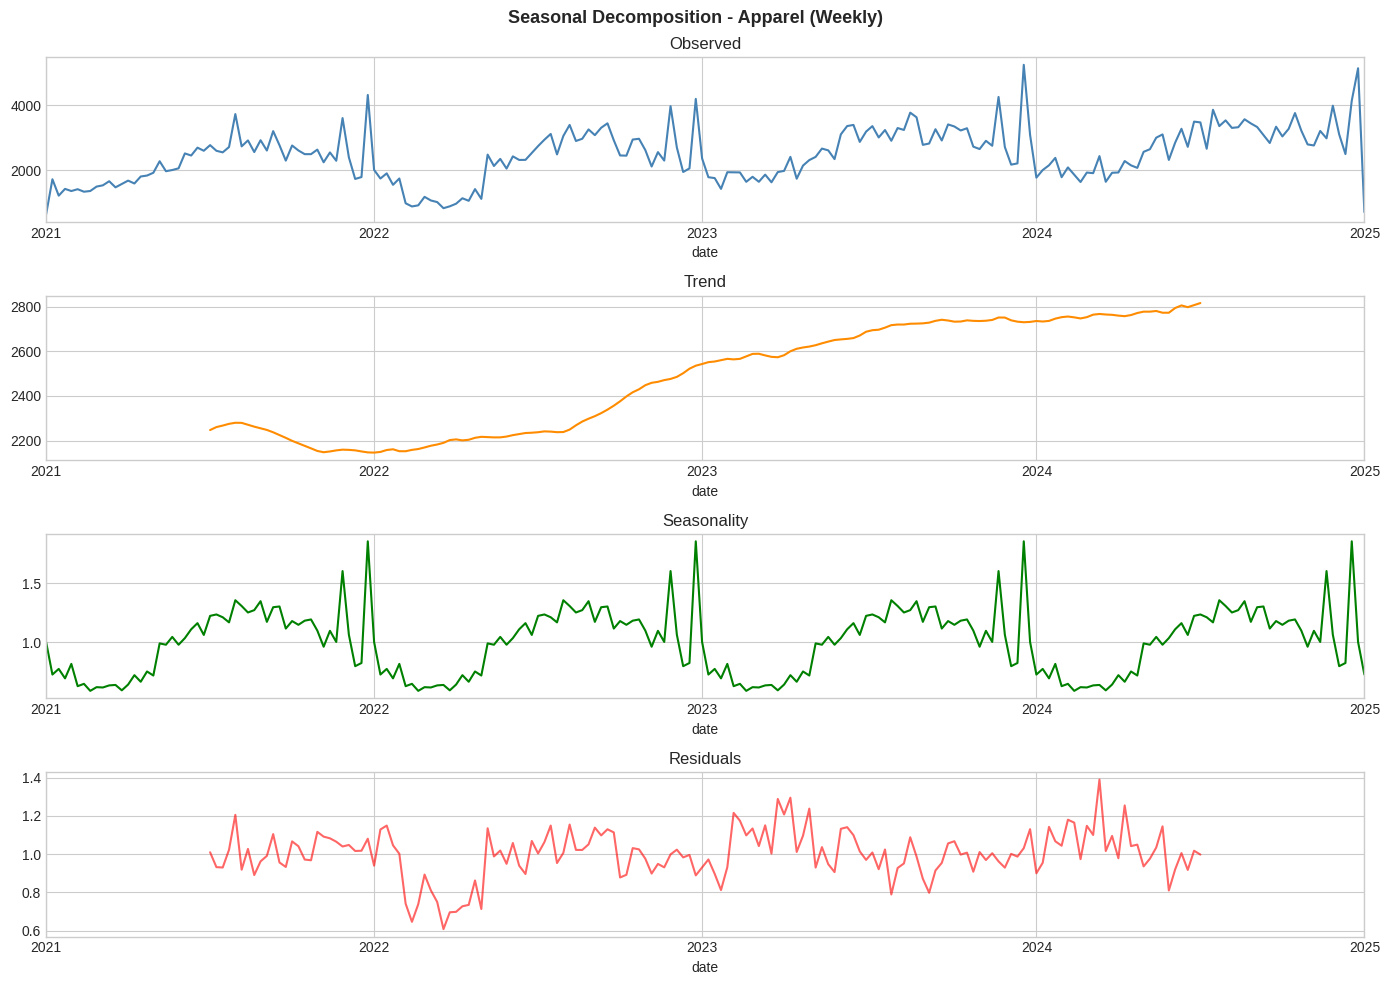

In [7]:
# Seasonal decomposition
sku_focus = CONFIG['skus'][0]
ts_weekly = (
    df_raw[df_raw['sku'] == sku_focus]
    .set_index('date')['demand']
    .resample('W').sum()
)
decomp = seasonal_decompose(ts_weekly, model='multiplicative', period=52)
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], color='steelblue'); axes[0].set_title('Observed')
decomp.trend.plot(ax=axes[1], color='darkorange'); axes[1].set_title('Trend')
decomp.seasonal.plot(ax=axes[2], color='green'); axes[2].set_title('Seasonality')
decomp.resid.plot(ax=axes[3], color='red', alpha=0.6); axes[3].set_title('Residuals')
plt.suptitle(f'Seasonal Decomposition - {sku_focus} (Weekly)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


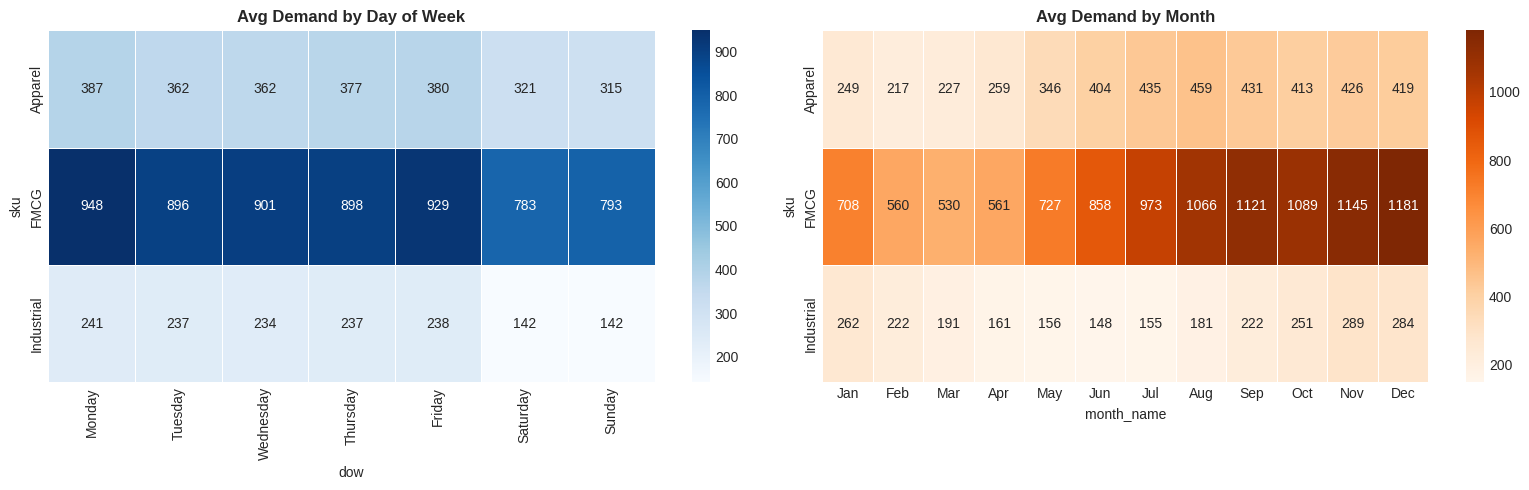

In [8]:
# Day-of-week and month demand heatmaps
df_raw['dow'] = df_raw['date'].dt.day_name()
df_raw['month_name'] = df_raw['date'].dt.strftime('%b')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_pivot = df_raw.groupby(['sku','dow'])['demand'].mean().unstack()[dow_order]
sns.heatmap(dow_pivot, ax=ax1, cmap='Blues', annot=True, fmt='.0f', linewidths=0.5)
ax1.set_title('Avg Demand by Day of Week', fontweight='bold')

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_pivot = df_raw.groupby(['sku','month_name'])['demand'].mean().unstack()[month_order]
sns.heatmap(month_pivot, ax=ax2, cmap='Oranges', annot=True, fmt='.0f', linewidths=0.5)
ax2.set_title('Avg Demand by Month', fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Feature Engineering


In [9]:
def engineer_features(df, target_col='demand'):
    df = df.sort_values(['sku', 'date']).copy()

    df['dayofweek']  = df['date'].dt.dayofweek
    df['month']      = df['date'].dt.month
    df['quarter']    = df['date'].dt.quarter
    df['dayofyear']  = df['date'].dt.dayofyear
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['year']       = df['date'].dt.year
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end']   = df['date'].dt.is_month_end.astype(int)
    df['is_quarter_end'] = df['date'].dt.is_quarter_end.astype(int)

    df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    for lag in [1, 2, 3, 7, 14, 21, 28]:
        df[f'lag_{lag}'] = df.groupby('sku')[target_col].shift(lag)

    for window in [7, 14, 28, 90]:
        df[f'roll_mean_{window}'] = df.groupby('sku')[target_col].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean())
        df[f'roll_std_{window}']  = df.groupby('sku')[target_col].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).std())
        df[f'roll_max_{window}']  = df.groupby('sku')[target_col].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).max())

    df['expanding_mean'] = df.groupby('sku')[target_col].transform(
        lambda x: x.shift(1).expanding().mean())

    df = pd.get_dummies(df, columns=['sku'], prefix='sku')
    return df


df_features = engineer_features(df_raw)
df_features = df_features.dropna()
print(f'Feature engineering complete. Shape: {df_features.shape}')


Feature engineering complete. Shape: (4299, 43)


## 6. Train / Test Split


In [10]:
cutoff_date = df_features['date'].max() - pd.Timedelta(days=CONFIG['test_size_days'])

train_df = df_features[df_features['date'] <= cutoff_date].copy()
test_df  = df_features[df_features['date'] >  cutoff_date].copy()

print(f'Train: {train_df.date.min().date()} to {train_df.date.max().date()} ({len(train_df):,} rows)')
print(f'Test:  {test_df.date.min().date()} to {test_df.date.max().date()} ({len(test_df):,} rows)')

drop_cols = ['date', 'demand', 'dow', 'month_name']
feature_columns = [c for c in df_features.columns if c not in drop_cols]

X_train = train_df[feature_columns]
y_train = train_df['demand']
X_test  = test_df[feature_columns]
y_test  = test_df['demand']

print(f'Features: {len(feature_columns)}')


Train: 2021-01-29 to 2024-10-02 (4,029 rows)
Test:  2024-10-03 to 2024-12-31 (270 rows)
Features: 39


## 7. Model Training


### 7a. XGBoost


In [11]:
print('Training XGBoost...')
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=CONFIG['seed'],
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric='mae'
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_preds = np.maximum(xgb_model.predict(X_test), 0)

xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_preds) * 100
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
print(f'XGBoost  -> MAE: {xgb_mae:.1f}  RMSE: {xgb_rmse:.1f}  MAPE: {xgb_mape:.2f}%')


Training XGBoost...
XGBoost  -> MAE: 101.6  RMSE: 157.6  MAPE: 18.52%


### 7b. LightGBM


In [12]:
print('Training LightGBM...')
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=CONFIG['seed'],
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=-1)]
)
lgb_preds = np.maximum(lgb_model.predict(X_test), 0)

lgb_mae  = mean_absolute_error(y_test, lgb_preds)
lgb_mape = mean_absolute_percentage_error(y_test, lgb_preds) * 100
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
print(f'LightGBM -> MAE: {lgb_mae:.1f}  RMSE: {lgb_rmse:.1f}  MAPE: {lgb_mape:.2f}%')


Training LightGBM...
LightGBM -> MAE: 101.8  RMSE: 160.2  MAPE: 18.65%


### 7c. Prophet (per SKU)


In [13]:
prophet_models = {}
prophet_forecasts = {}
prophet_metrics = {}

for sku in CONFIG['skus']:
    sku_train = df_raw[(df_raw['sku'] == sku) & (df_raw['date'] <= cutoff_date)][['date', 'demand', 'is_promo']].copy()
    sku_test  = df_raw[(df_raw['sku'] == sku) & (df_raw['date'] >  cutoff_date)][['date', 'demand']].copy()
    sku_train.columns = ['ds', 'y', 'is_promo']
    sku_test.columns  = ['ds', 'y']

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.15,
        seasonality_prior_scale=10,
        interval_width=0.95
    )
    m.add_regressor('is_promo')
    m.fit(sku_train)

    future = m.make_future_dataframe(periods=CONFIG['test_size_days'] + CONFIG['forecast_days'], freq='D')
    future['is_promo'] = 0
    forecast = m.predict(future)
    prophet_models[sku] = m
    prophet_forecasts[sku] = forecast

    merged = sku_test.merge(forecast[['ds', 'yhat']], on='ds')
    merged['yhat'] = merged['yhat'].clip(lower=0)
    mae  = mean_absolute_error(merged['y'], merged['yhat'])
    mape = mean_absolute_percentage_error(merged['y'], merged['yhat']) * 100
    rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
    prophet_metrics[sku] = {'MAE': mae, 'MAPE': mape, 'RMSE': rmse}
    print(f'  {sku:12s} -> MAE: {mae:.1f}  MAPE: {mape:.2f}%')

avg_prophet_mae  = np.mean([v['MAE']  for v in prophet_metrics.values()])
avg_prophet_mape = np.mean([v['MAPE'] for v in prophet_metrics.values()])
avg_prophet_rmse = np.mean([v['RMSE'] for v in prophet_metrics.values()])
print(f'\nProphet (avg) -> MAE: {avg_prophet_mae:.1f}  MAPE: {avg_prophet_mape:.2f}%')


  Apparel      -> MAE: 154.3  MAPE: 26.27%
  FMCG         -> MAE: 280.0  MAPE: 17.11%
  Industrial   -> MAE: 47.7  MAPE: 16.91%

Prophet (avg) -> MAE: 160.7  MAPE: 20.10%


## 8. Model Evaluation and Comparison


=== Model Comparison ===
   Model    MAE   RMSE  MAPE%
 XGBoost 101.59 157.63  18.52
LightGBM 101.76 160.25  18.65
 Prophet 160.67 288.58  20.10

Best model by MAE: XGBoost


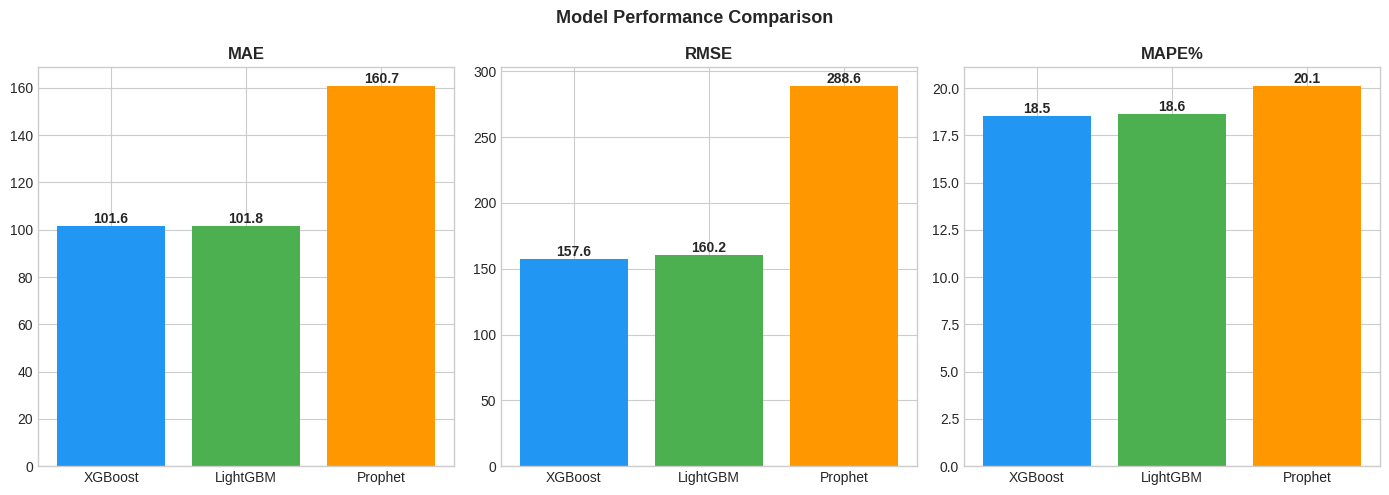

In [14]:
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'Prophet'],
    'MAE':   [xgb_mae,  lgb_mae,  avg_prophet_mae],
    'RMSE':  [xgb_rmse, lgb_rmse, avg_prophet_rmse],
    'MAPE%': [xgb_mape, lgb_mape, avg_prophet_mape]
}).sort_values('MAE')

print('=== Model Comparison ===')
print(results.to_string(index=False))
print(f"\nBest model by MAE: {results.iloc[0]['Model']}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE%']):
    bars = ax.bar(results['Model'], results[metric], color=colors)
    ax.set_title(metric, fontweight='bold')
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


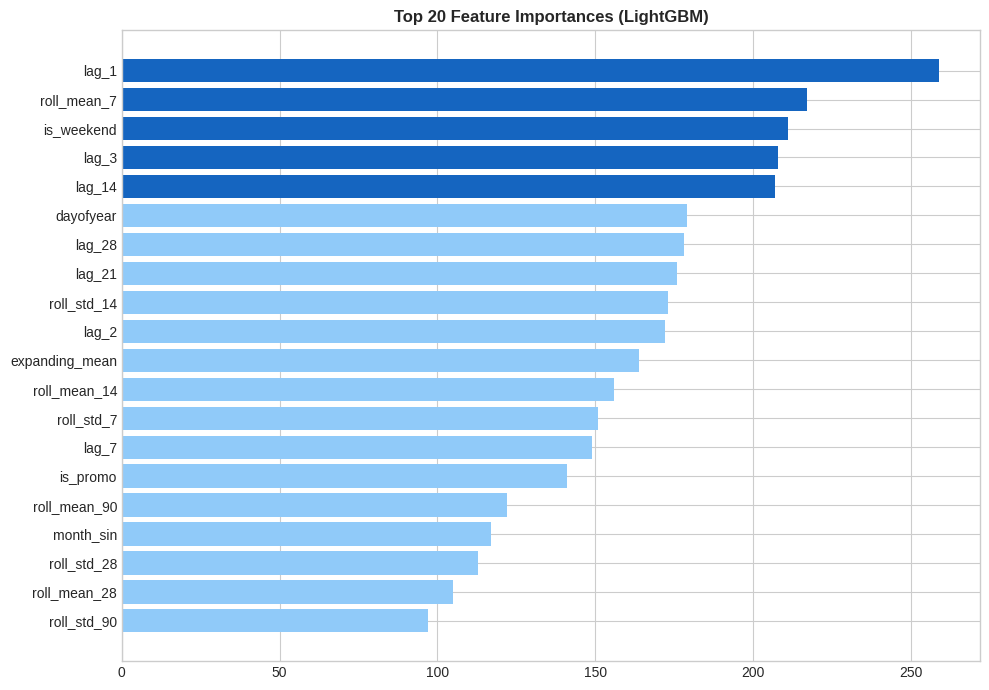

In [15]:
# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=['#1565C0' if i < 5 else '#90CAF9' for i in range(len(importance_df))])
ax.set_title('Top 20 Feature Importances (LightGBM)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [16]:
# Actual vs Predicted on test set
test_plot = test_df.copy()
test_plot['lgb_pred'] = lgb_preds
sku_cols_plot = [c for c in test_plot.columns if c.startswith('sku_')]
test_plot['sku'] = test_plot[sku_cols_plot].idxmax(axis=1).str.replace('sku_', '')

fig = make_subplots(rows=len(CONFIG['skus']), cols=1,
                    subplot_titles=[f'{s} - Actual vs Predicted' for s in CONFIG['skus']])

for i, sku in enumerate(CONFIG['skus'], 1):
    sub = test_plot[test_plot['sku'] == sku].sort_values('date')
    fig.add_trace(go.Scatter(x=sub['date'], y=sub['demand'], name='Actual',
                             line=dict(color='steelblue'), showlegend=(i==1)), row=i, col=1)
    fig.add_trace(go.Scatter(x=sub['date'], y=sub['lgb_pred'], name='Predicted',
                             line=dict(color='orange', dash='dash'), showlegend=(i==1)), row=i, col=1)

fig.update_layout(height=200*len(CONFIG['skus']), title_text='Actual vs Predicted (Test Set)',
                  template='plotly_white', showlegend=True)
fig.show()


## 9. Future Demand Forecasting


In [17]:
last_date = df_raw['date'].max()
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=CONFIG['forecast_days'],
    freq='D'
)

future_records = []
for sku in CONFIG['skus']:
    for date in future_dates:
        future_records.append({
            'date': date, 'sku': sku, 'demand': np.nan,
            'is_promo': 0,
            'is_weekend': int(date.dayofweek >= 5),
            'is_disruption': 0
        })

df_future_raw = pd.DataFrame(future_records)
df_combined = pd.concat([df_raw, df_future_raw], ignore_index=True)
df_combined_feat = engineer_features(df_combined, target_col='demand')
df_future_feat = df_combined_feat[df_combined_feat['date'] > last_date].copy()

for col in feature_columns:
    if col not in df_future_feat.columns:
        df_future_feat[col] = 0
df_future_feat = df_future_feat.fillna(method='ffill').fillna(0)

X_future = df_future_feat[feature_columns]
lgb_future_preds = np.maximum(lgb_model.predict(X_future), 0)
df_future_feat = df_future_feat.copy()
df_future_feat['lgb_forecast'] = lgb_future_preds

sku_cols_f = [c for c in df_future_feat.columns if c.startswith('sku_')]
df_future_feat['sku'] = df_future_feat[sku_cols_f].idxmax(axis=1).str.replace('sku_', '')

print(f'Forecast generated: {CONFIG["forecast_days"]} days')
print(f'Period: {future_dates[0].date()} to {future_dates[-1].date()}')


Forecast generated: 90 days
Period: 2025-01-01 to 2025-03-31


In [18]:
# Plot future forecasts
fig = make_subplots(rows=len(CONFIG['skus']), cols=1,
                    subplot_titles=[f'{s} - Demand Forecast' for s in CONFIG['skus']])

history_window = 120
for i, sku in enumerate(CONFIG['skus'], 1):
    hist = df_raw[df_raw['sku'] == sku].tail(history_window)
    fut  = df_future_feat[df_future_feat['sku'] == sku]

    if sku in prophet_forecasts:
        pf = prophet_forecasts[sku]
        pf_future = pf[pf['ds'] > last_date]
        fig.add_trace(go.Scatter(
            x=pd.concat([pf_future['ds'], pf_future['ds'][::-1]]),
            y=pd.concat([pf_future['yhat_upper'], pf_future['yhat_lower'][::-1]]),
            fill='toself', fillcolor='rgba(255,165,0,0.15)',
            line=dict(color='rgba(255,255,255,0)'), name='95% CI',
            showlegend=(i==1)
        ), row=i, col=1)

    fig.add_trace(go.Scatter(x=hist['date'], y=hist['demand'], name='Historical',
                             line=dict(color='steelblue'), showlegend=(i==1)), row=i, col=1)
    fig.add_trace(go.Scatter(x=fut['date'], y=fut['lgb_forecast'], name='Forecast',
                             line=dict(color='darkorange', dash='dash'), showlegend=(i==1)), row=i, col=1)

fig.update_layout(height=220*len(CONFIG['skus']),
                  title_text=f"{CONFIG['forecast_days']}-Day Demand Forecast by SKU",
                  template='plotly_white')
fig.show()


## 10. Inventory Optimisation and Resource Allocation


In [19]:
def compute_inventory_recommendations(future_df, historical_df, config):
    z = config['service_level_z']
    records = []
    for sku in config['skus']:
        lead_time = config['lead_times'][sku]
        hist = historical_df[historical_df['sku'] == sku]['demand']
        avg_daily = hist.mean()
        std_daily = hist.std()
        fut = future_df[future_df['sku'] == sku]['lgb_forecast']
        forecast_total = fut.sum()
        forecast_avg   = fut.mean()
        forecast_peak  = fut.max()
        safety_stock  = round(z * std_daily * np.sqrt(lead_time))
        reorder_point = round(avg_daily * lead_time + safety_stock)
        annual_demand = forecast_avg * 365
        eoq = round(np.sqrt((2 * annual_demand * 50) / 0.25))
        pallet_positions = round(reorder_point * 0.01)
        daily_labour_hrs = round(forecast_avg * 0.005, 1)
        records.append({
            'SKU': sku,
            'Lead Time (days)': lead_time,
            'Avg Daily Demand': round(avg_daily, 1),
            'Demand Std Dev': round(std_daily, 1),
            'Forecast Total': round(forecast_total),
            'Forecast Daily Avg': round(forecast_avg, 1),
            'Forecast Peak Day': round(forecast_peak),
            'Safety Stock': safety_stock,
            'Reorder Point': reorder_point,
            'EOQ': eoq,
            'Pallet Positions': pallet_positions,
            'Daily Labour Hrs': daily_labour_hrs,
        })
    return pd.DataFrame(records)


inv_df = compute_inventory_recommendations(df_future_feat, df_raw, CONFIG)
print('=== Inventory Optimisation Recommendations ===')
print(inv_df.to_string(index=False))


=== Inventory Optimisation Recommendations ===
       SKU  Lead Time (days)  Avg Daily Demand  Demand Std Dev  Forecast Total  Forecast Daily Avg  Forecast Peak Day  Safety Stock  Reorder Point   EOQ  Pallet Positions  Daily Labour Hrs
   Apparel                21            357.70          158.20           31884              354.30                636          1196           8708  7192                87              1.80
      FMCG                 7            878.50          351.50           72324              803.60                905          1534           7684 10832                77              4.00
Industrial                30            210.20           82.90           28968              321.90                357           750           7056  6855                71              1.60


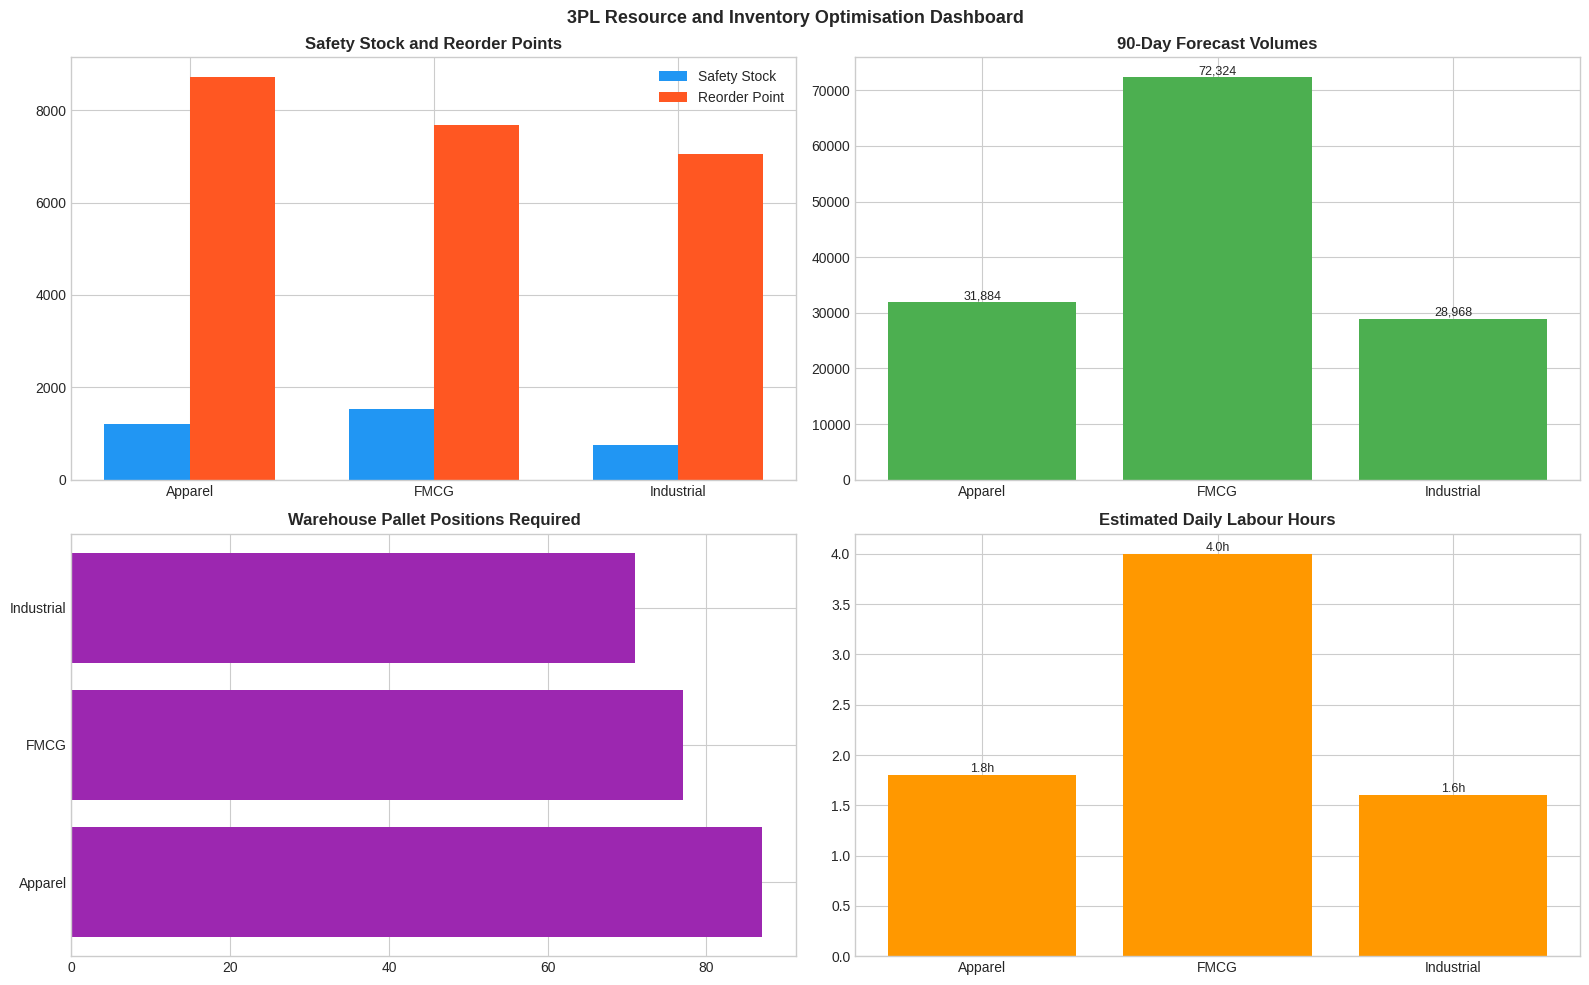

In [20]:
# Inventory visualisations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

x = np.arange(len(inv_df))
w = 0.35
axes[0,0].bar(x - w/2, inv_df['Safety Stock'],  w, label='Safety Stock',  color='#2196F3')
axes[0,0].bar(x + w/2, inv_df['Reorder Point'], w, label='Reorder Point', color='#FF5722')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(inv_df['SKU'])
axes[0,0].set_title('Safety Stock and Reorder Points', fontweight='bold')
axes[0,0].legend()

axes[0,1].bar(inv_df['SKU'], inv_df['Forecast Total'], color='#4CAF50')
axes[0,1].set_title(f"{CONFIG['forecast_days']}-Day Forecast Volumes", fontweight='bold')
for bar, val in zip(axes[0,1].patches, inv_df['Forecast Total']):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                   f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

axes[1,0].barh(inv_df['SKU'], inv_df['Pallet Positions'], color='#9C27B0')
axes[1,0].set_title('Warehouse Pallet Positions Required', fontweight='bold')

axes[1,1].bar(inv_df['SKU'], inv_df['Daily Labour Hrs'], color='#FF9800')
axes[1,1].set_title('Estimated Daily Labour Hours', fontweight='bold')
for bar, val in zip(axes[1,1].patches, inv_df['Daily Labour Hrs']):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                   f'{val:.1f}h', ha='center', va='bottom', fontsize=9)

plt.suptitle('3PL Resource and Inventory Optimisation Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


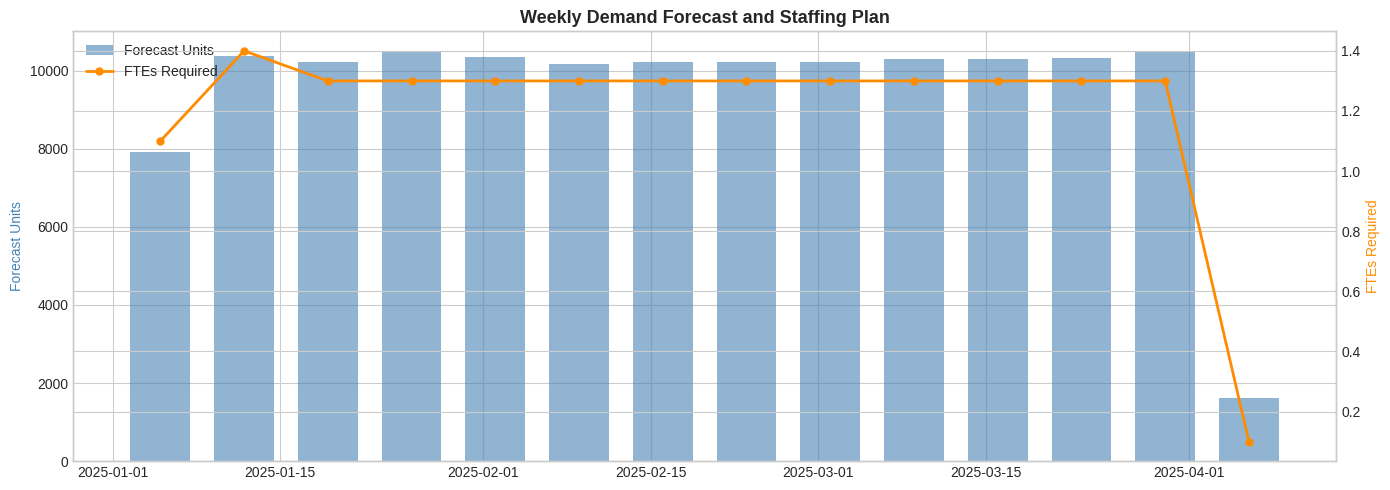


=== Weekly Staffing Plan ===
week_start  forecast_units  labour_hours  fte_needed
2025-01-05         7919.40         39.60        1.10
2025-01-12        10366.50         51.80        1.40
2025-01-19        10209.90         51.00        1.30
2025-01-26        10480.10         52.40        1.30
2025-02-02        10354.40         51.80        1.30
2025-02-09        10175.60         50.90        1.30
2025-02-16        10211.70         51.10        1.30
2025-02-23        10211.70         51.10        1.30
2025-03-02        10225.40         51.10        1.30
2025-03-09        10298.60         51.50        1.30
2025-03-16        10302.80         51.50        1.30
2025-03-23        10328.20         51.60        1.30
2025-03-30        10478.50         52.40        1.30
2025-04-06         1613.10          8.10        0.10


In [21]:
# Weekly staffing plan
weekly_forecast = df_future_feat.groupby(
    [pd.Grouper(key='date', freq='W'), 'sku']
)['lgb_forecast'].sum().reset_index()
weekly_forecast.columns = ['week_start', 'sku', 'forecast_units']
weekly_forecast['labour_hours'] = weekly_forecast['forecast_units'] * 0.005
weekly_forecast['fte_needed']   = (weekly_forecast['labour_hours'] / 40).round(1)

total_weekly = weekly_forecast.groupby('week_start')[['forecast_units', 'labour_hours', 'fte_needed']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.bar(total_weekly['week_start'], total_weekly['forecast_units'], width=5, alpha=0.6,
        color='steelblue', label='Forecast Units')
ax2.plot(total_weekly['week_start'], total_weekly['fte_needed'], 'o-',
         color='darkorange', linewidth=2, markersize=5, label='FTEs Required')
ax1.set_ylabel('Forecast Units', color='steelblue')
ax2.set_ylabel('FTEs Required', color='darkorange')
plt.title('Weekly Demand Forecast and Staffing Plan', fontweight='bold', fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

print('\n=== Weekly Staffing Plan ===')
print(total_weekly.round(1).to_string(index=False))


## 11. Export Results


In [22]:
inv_df.to_csv('inventory_recommendations.csv', index=False)

forecast_export = df_future_feat[['date', 'sku', 'lgb_forecast']].copy()
forecast_export.columns = ['date', 'sku', 'forecast_units']
forecast_export.to_csv('demand_forecast.csv', index=False)

weekly_forecast.to_csv('weekly_staffing_plan.csv', index=False)
results.to_csv('model_metrics.csv', index=False)

print('Exports complete:')
print('  inventory_recommendations.csv')
print('  demand_forecast.csv')
print('  weekly_staffing_plan.csv')
print('  model_metrics.csv')
forecast_export.head(20)


Exports complete:
  inventory_recommendations.csv
  demand_forecast.csv
  weekly_staffing_plan.csv
  model_metrics.csv


,date,sku,forecast_units
4383,2025-01-01,Apparel,610.97
4384,2025-01-02,Apparel,624.04
4385,2025-01-03,Apparel,617.94
4386,2025-01-04,Apparel,500.52
4387,2025-01-05,Apparel,507.20
4388,2025-01-06,Apparel,635.86
4389,2025-01-07,Apparel,603.52
4390,2025-01-08,Apparel,305.16
4391,2025-01-09,Apparel,343.10
4392,2025-01-10,Apparel,340.18


## 12. Summary and Next Steps

### What this notebook delivers

| Output | Description |
|--------|-------------|
| Demand Forecast | Daily unit demand per SKU for the next N days |
| Safety Stock | Buffer inventory at your target service level |
| Reorder Points | Trigger level for new purchase orders |
| EOQ | Optimal batch size to minimise total inventory cost |
| Pallet Positions | Warehouse space requirement per SKU |
| Staffing Plan | Weekly FTE headcount for fulfilment |

### How to use your own data

1. Set `CONFIG['data_source'] = 'csv'`
2. Upload your file to Colab
3. Set `CONFIG['csv_path']` to the file path
4. CSV must contain columns: `date`, `sku`, `demand`